# Students' Social Network Profile Clustering

**End-to-end project**: segmenting ~30,000 high-school students into
interest-based personas using keyword counts mined from their social-network
profiles (graduation years 2006–2009).

**Notebook roadmap**
1. Load the dataset
2. Exploratory Data Analysis (EDA) + visualizations
3. Distribution / skewness checks and transformations
4. Outlier detection/treatment and feature scaling
5. Clustering model: K-Means, Hierarchical, and DBSCAN — with silhouette
   comparison
6. Demographic profiling and trend analysis over time
7. Save the production model (used by `app.py` / Streamlit)

All reusable logic lives in the `src/` package (`config.py`,
`data_preprocessing.py`, `eda.py`, `clustering.py`) so the same functions
power this notebook, `run_pipeline.py`, and the Streamlit app — no
duplicated code, one source of truth.


In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, eda, clustering
from src.data_preprocessing import (
    load_data, treat_missing_values, check_skewness, treat_skewness,
    detect_outliers_iqr, cap_outliers_iqr, scale_features,
)

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 100
print('Setup complete.')


Setup complete.


## 1. Load the dataset

Dataset: *Students' Social Network Profile Clustering* (Kaggle). 36 interest-keyword count columns + 4 demographic columns (`gradyear`, `gender`, `age`, `NumberOffriends`).

In [2]:
df_raw = load_data()
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (15000, 40)


,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,tennis,sports,cute,sex,sexy,hot,kissed,dance,band,marching,music,rock,god,church,jesus,bible,hair,dress,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,None,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2007,F,17.410,49,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,2007,F,17.511,41,0,0,0,0,0,0,0,1,0,0,0,3,0,0,0,0,0,0,1,2,0,1,0,0,4,0,0,1,0,0,0,0,0,0,1,1
3,2006,F,NaN,36,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2008,F,16.657,1,0,0,0,0,0,1,0,0,3,0,6,0,2,0,0,0,0,0,1,0,1,1,0,0,5,0,0,0,0,3,0,0,0,0,0,0


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 40 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gradyear         15000 non-null  int64  
 1   gender           13663 non-null  object 
 2   age              12228 non-null  float64
 3   NumberOffriends  15000 non-null  int64  
 4   basketball       15000 non-null  int64  
 5   football         15000 non-null  int64  
 6   soccer           15000 non-null  int64  
 7   softball         15000 non-null  int64  
 8   volleyball       15000 non-null  int64  
 9   swimming         15000 non-null  int64  
 10  cheerleading     15000 non-null  int64  
 11  baseball         15000 non-null  int64  
 12  tennis           15000 non-null  int64  
 13  sports           15000 non-null  int64  
 14  cute             15000 non-null  int64  
 15  sex              15000 non-null  int64  
 16  sexy             15000 non-null  int64  
 17  hot              15000 

In [4]:
df_raw.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gradyear,15000.0,NaN,NaN,NaN,2007.496933,1.116516,2006.0,2006.0,2008.0,2008.0,2009.0
gender,13663,2,F,11057,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,12228.0,NaN,NaN,NaN,17.988164,7.715857,4.309,16.331,17.295,18.264,106.927
NumberOffriends,15000.0,NaN,NaN,NaN,29.834533,35.386649,0.0,3.0,20.0,44.0,605.0
basketball,15000.0,NaN,NaN,NaN,0.267,0.788851,0.0,0.0,0.0,0.0,22.0
football,15000.0,NaN,NaN,NaN,0.255467,0.70226,0.0,0.0,0.0,0.0,9.0
soccer,15000.0,NaN,NaN,NaN,0.222,0.92042,0.0,0.0,0.0,0.0,22.0
softball,15000.0,NaN,NaN,NaN,0.159667,0.737344,0.0,0.0,0.0,0.0,17.0
volleyball,15000.0,NaN,NaN,NaN,0.142933,0.638747,0.0,0.0,0.0,0.0,14.0
swimming,15000.0,NaN,NaN,NaN,0.135,0.548691,0.0,0.0,0.0,0.0,31.0


## 2. Exploratory Data Analysis (EDA)

### 2.1 Missing values

In [5]:
df_raw.isnull().sum()[df_raw.isnull().sum() > 0]


gender    1337
age       2772
dtype: int64

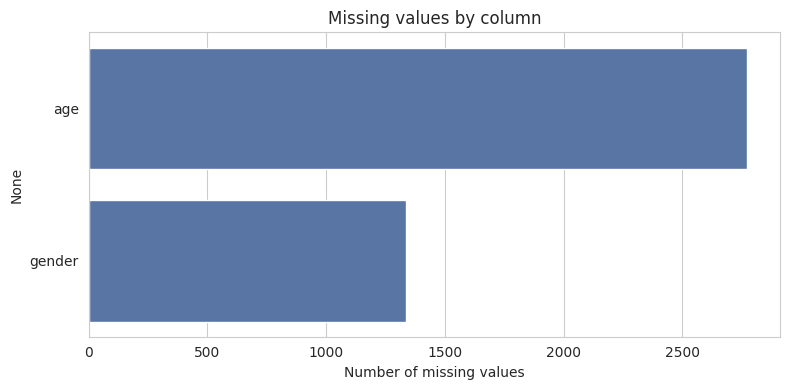

In [6]:
fig = eda.plot_missing_values(df_raw)
plt.show()


Only `gender` (~9%) and `age` (~17%, plus some biologically implausible values like age 3 or age 108) have missing/invalid data. Every interest-word column and `NumberOffriends` is fully populated (a student simply didn't use that word -> count of 0).

### 2.2 Demographic distributions

/home/claude/student_clustering_project/src/eda.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="gender", data=df, order=order, ax=ax, palette="Set2")


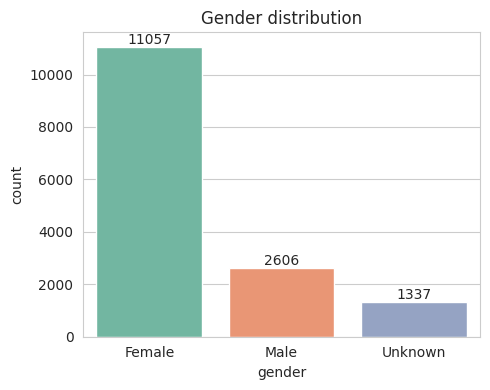

In [7]:
df_demo_clean = treat_missing_values(df_raw)  # only for plotting-friendly gender labels here

fig = eda.plot_gender_distribution(df_demo_clean)
plt.show()


/home/claude/student_clustering_project/src/eda.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="gradyear", data=df, ax=ax, palette="Set2",


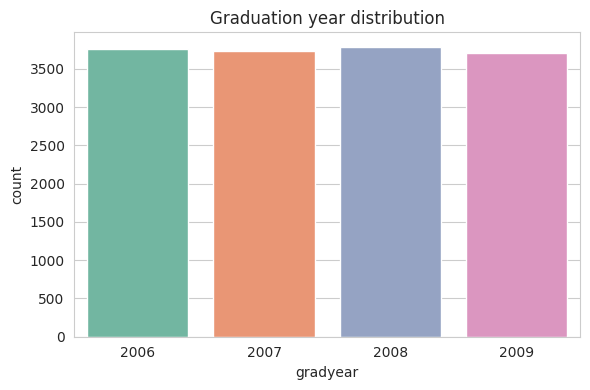

In [8]:
fig = eda.plot_grad_year_distribution(df_raw)
plt.show()


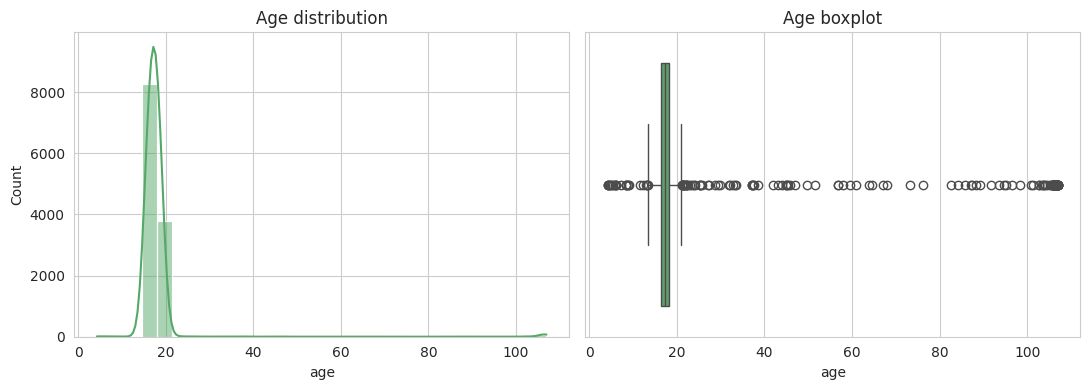

In [9]:
fig = eda.plot_age_distribution(df_raw)
plt.show()


### 2.3 Interest keywords

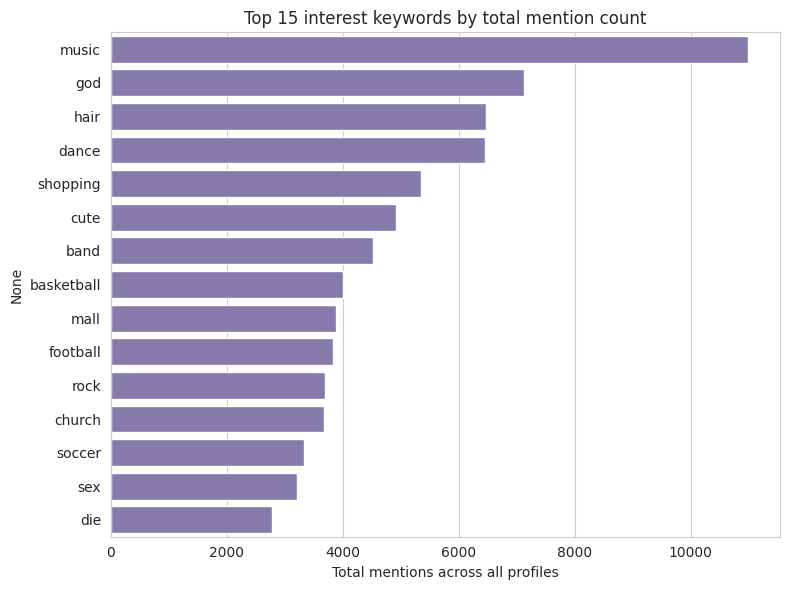

In [10]:
fig = eda.plot_top_interest_words(df_raw, config.INTEREST_COLS, top_n=15)
plt.show()


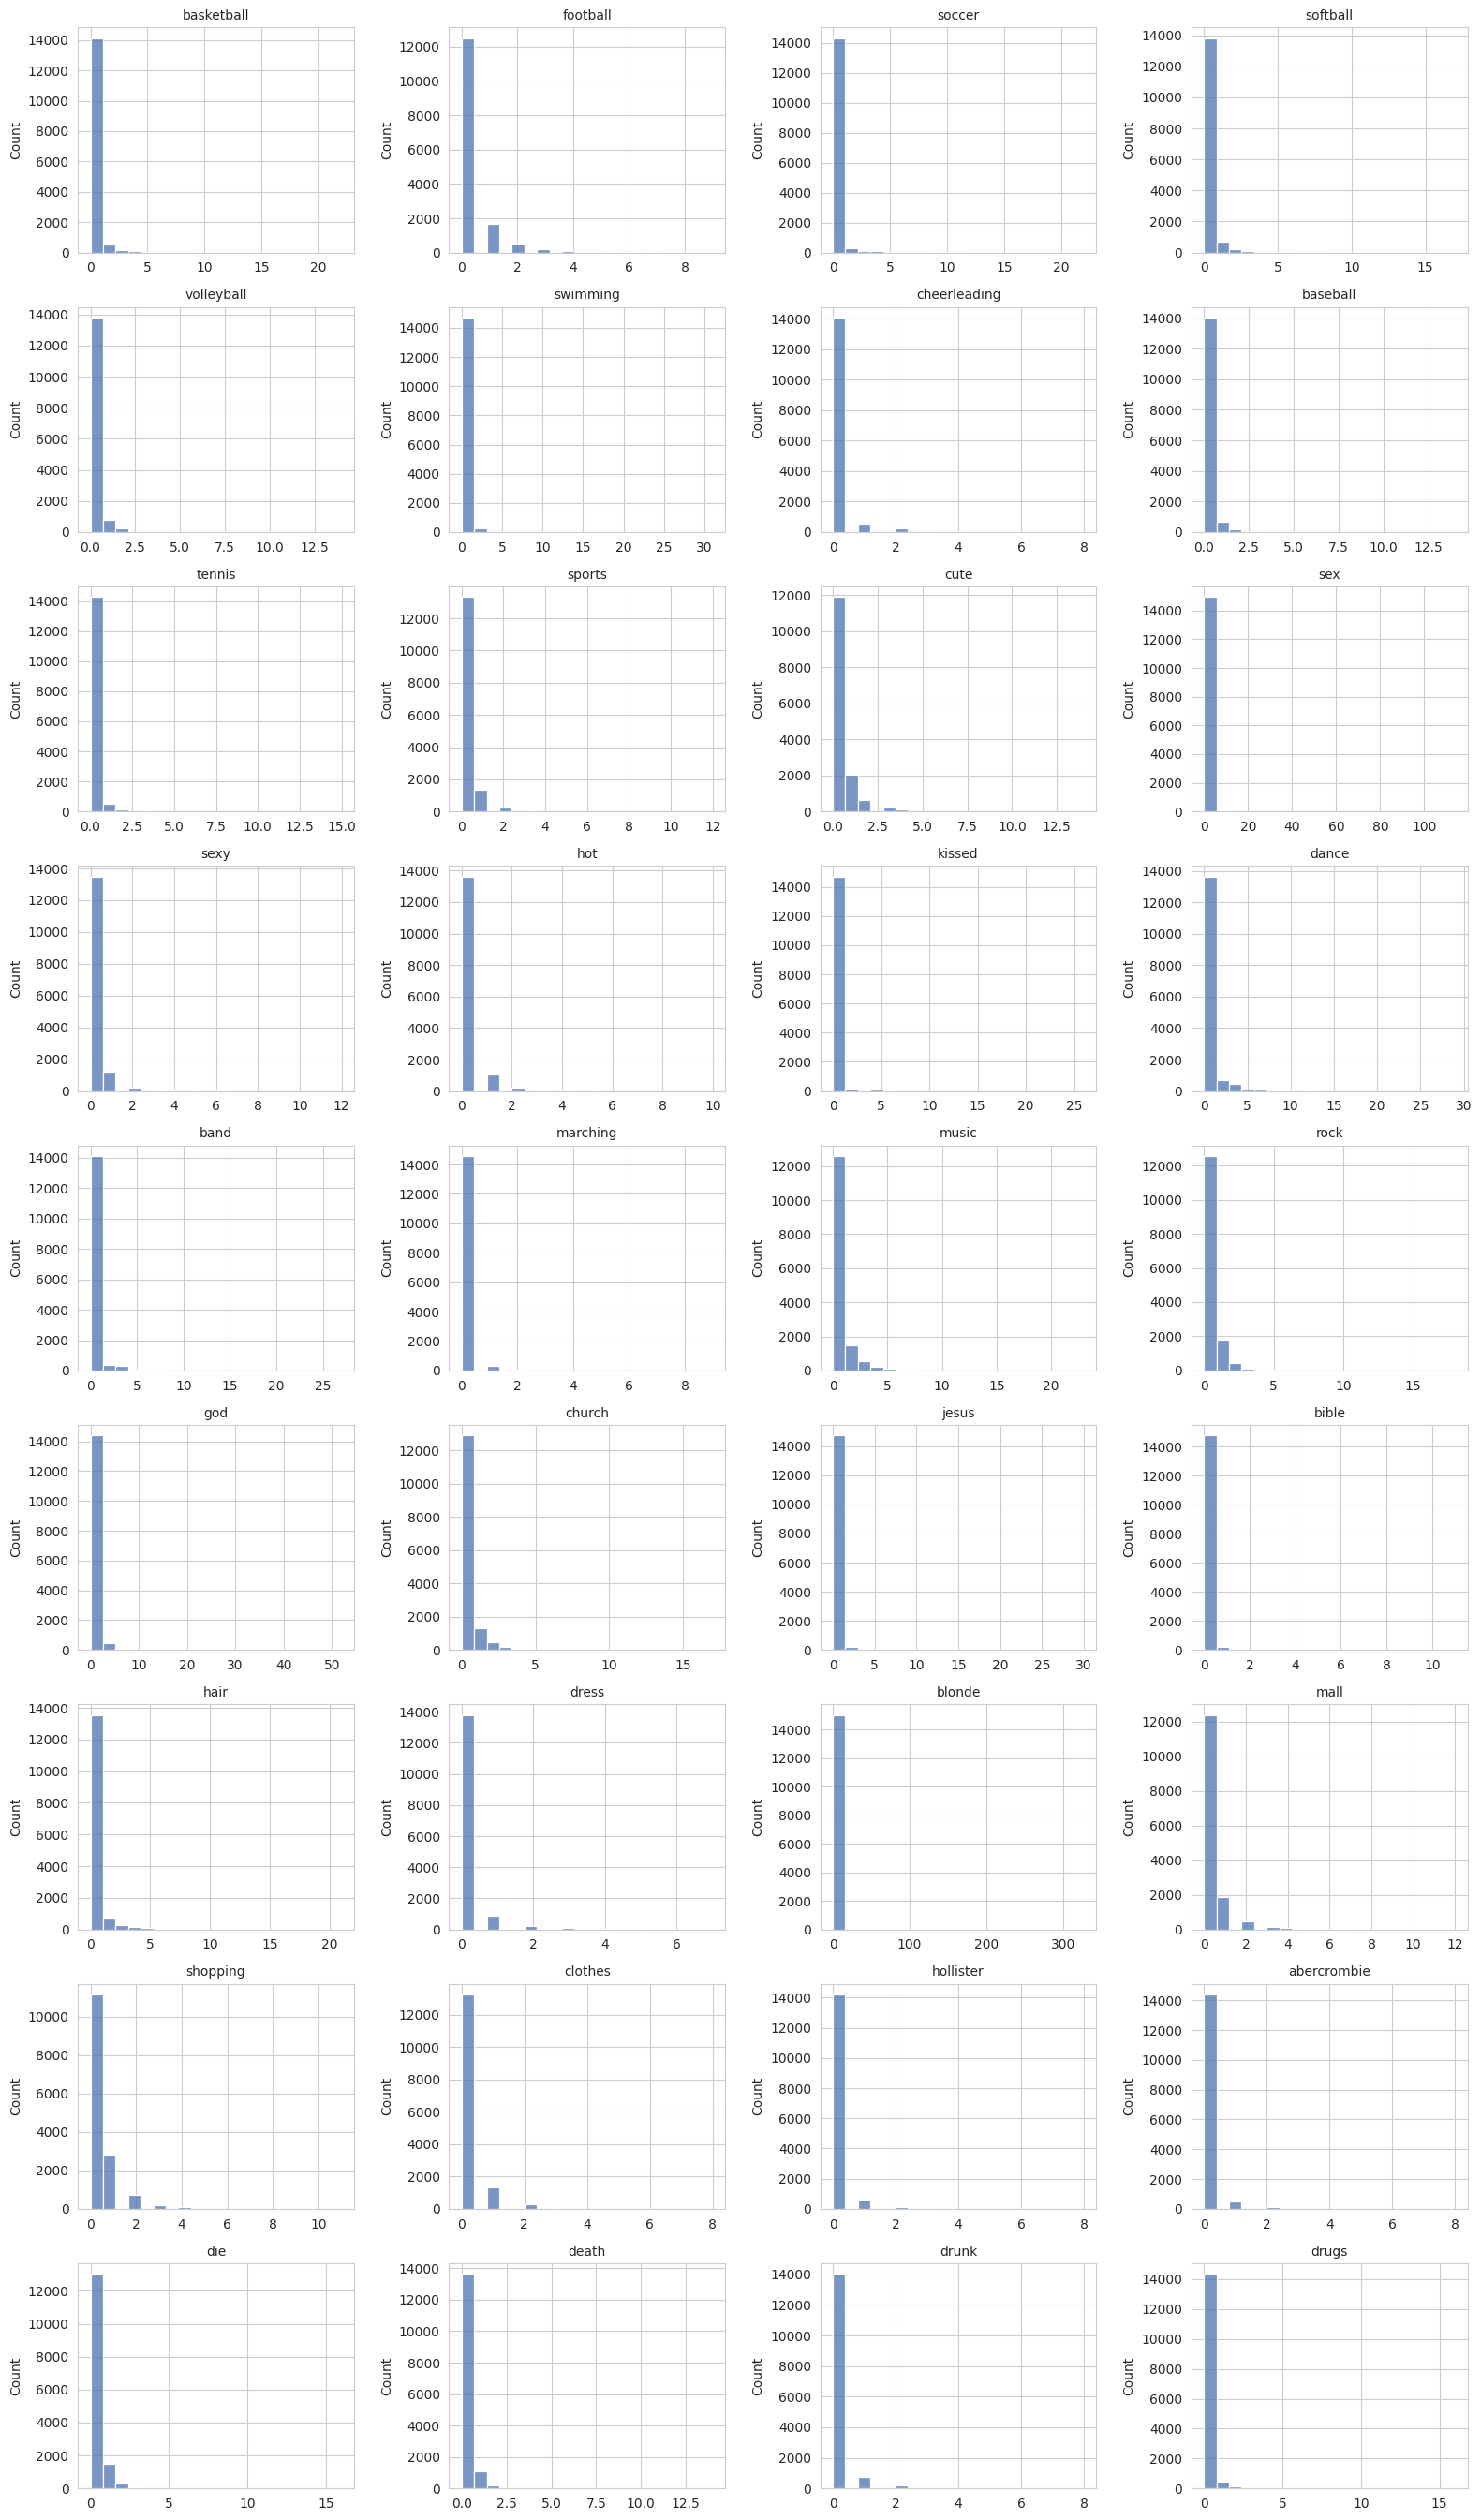

In [11]:
fig = eda.plot_numeric_distributions(df_raw, config.INTEREST_COLS)
plt.show()


### 2.4 Correlations

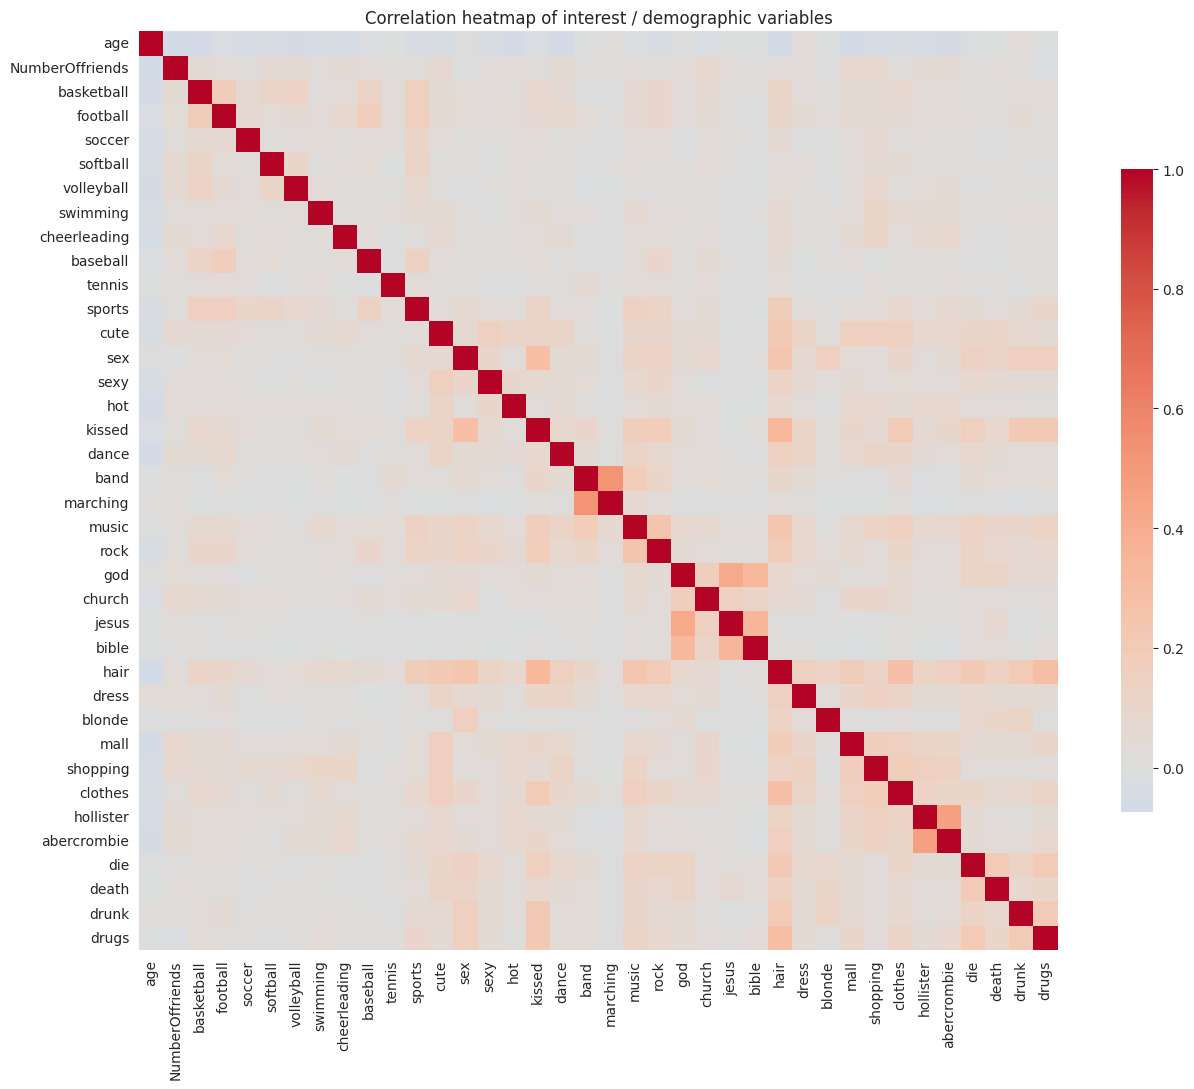

In [12]:
fig = eda.plot_correlation_heatmap(df_demo_clean, ['age', 'NumberOffriends'] + config.INTEREST_COLS)
plt.show()


Sports words correlate strongly with each other, as do the appearance/romance words and the religion words — a first sign that the 36 keywords cluster into a handful of coherent *themes*, which is exactly what we'd expect student personas to be built from.

### 2.5 Trend over time (preliminary)
A first look at how each interest theme trends across graduation years, before any clustering.

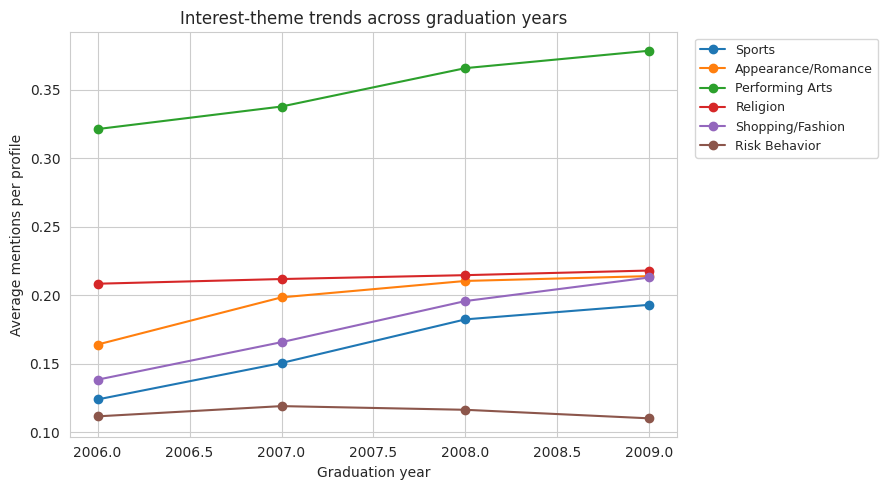

In [13]:
fig = eda.plot_theme_trend_over_years(df_demo_clean)
plt.show()


## 3. Missing values, skewness & transformations

### 3.1 Handling missing values
- `age`: implausible values (<10 or >25) are nulled out, then imputed with the **median age within the same graduation year** — a good proxy since students in the same grad year cluster tightly in age.
- `gender`: missing values become their own `"Unknown"` category rather than being dropped or mode-imputed, since non-disclosure can itself be informative.

In [14]:
df_clean = treat_missing_values(df_raw)
print("Remaining missing values:")
print(df_clean.isnull().sum().sum())
df_clean[['gradyear', 'gender', 'age', 'NumberOffriends']].head()


Remaining missing values:
0


,gradyear,gender,age,NumberOffriends
0,2007,Unknown,17.703,0
1,2007,Female,17.410,49
2,2007,Female,17.511,41
3,2006,Female,18.683,36
4,2008,Female,16.657,1


### 3.2 Skewness check

In [15]:
numeric_cols = ['age', 'NumberOffriends'] + config.INTEREST_COLS
skewness = check_skewness(df_clean, numeric_cols)
skewness


blonde             117.250830
sex                 49.972125
bible               21.417635
jesus               19.160195
swimming            16.380904
kissed              12.866542
drugs               12.508258
marching            11.670519
god                 11.490218
tennis              11.236150
baseball             9.344208
abercrombie          8.169792
death                8.104098
softball             7.842373
hollister            7.788430
volleyball           7.548032
drunk                7.545941
band                 7.413696
soccer               7.277183
die                  6.993131
cheerleading         6.917809
sexy                 6.678510
rock                 6.450876
sports               5.877223
dance                5.728317
hot                  5.685510
basketball           5.681317
church               5.549156
dress                5.546623
mall                 4.697283
hair                 4.637419
clothes              4.572851
music                4.378561
cute      

Most of the interest-keyword counts are heavily right-skewed (most students mention a word 0 times, a few mention it a lot) — expected for count data. We log1p-transform every column with |skew| > 1.

In [16]:
df_transformed, log_cols = treat_skewness(df_clean, numeric_cols)
print(f"Log1p-transformed {len(log_cols)} of {len(numeric_cols)} columns:")
print(log_cols)


Log1p-transformed 37 of 38 columns:
['blonde', 'sex', 'bible', 'jesus', 'swimming', 'kissed', 'drugs', 'marching', 'god', 'tennis', 'baseball', 'abercrombie', 'death', 'softball', 'hollister', 'volleyball', 'drunk', 'band', 'soccer', 'die', 'cheerleading', 'sexy', 'rock', 'sports', 'dance', 'hot', 'basketball', 'church', 'dress', 'mall', 'hair', 'clothes', 'music', 'cute', 'football', 'shopping', 'NumberOffriends']


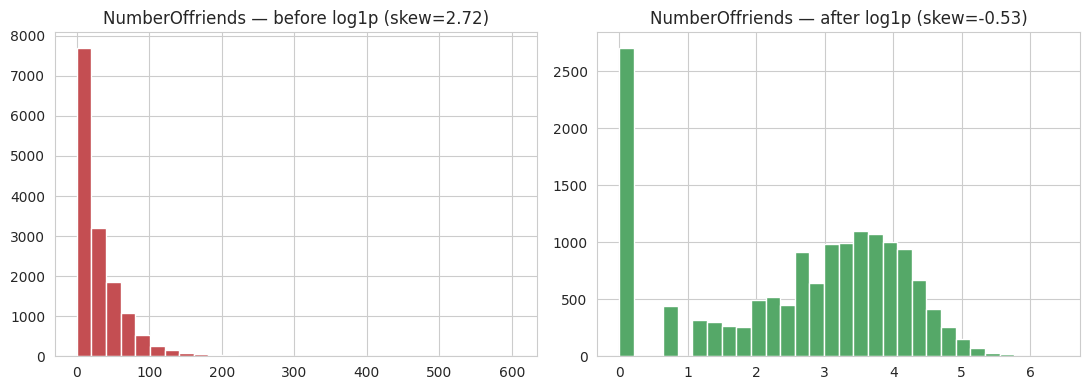

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df_clean['NumberOffriends'], bins=30, color='#C44E52')
axes[0].set_title('NumberOffriends — before log1p (skew=%.2f)' % df_clean['NumberOffriends'].skew())
axes[1].hist(df_transformed['NumberOffriends'], bins=30, color='#55A868')
axes[1].set_title('NumberOffriends — after log1p (skew=%.2f)' % df_transformed['NumberOffriends'].skew())
plt.tight_layout()
plt.show()


## 4. Outlier treatment & feature scaling

### 4.1 Outlier detection (IQR method)

In [18]:
outlier_summary = detect_outliers_iqr(df_transformed, numeric_cols)
outlier_summary


,column,lower_bound,upper_bound,n_outliers,pct_outliers
26,hair,0.000000,0.000000,3407,22.71
17,dance,0.000000,0.000000,3323,22.15
12,cute,0.000000,0.000000,3114,20.76
29,mall,0.000000,0.000000,2633,17.55
3,football,0.000000,0.000000,2499,16.66
21,rock,0.000000,0.000000,2452,16.35
2,basketball,0.000000,0.000000,2412,16.08
18,band,0.000000,0.000000,2209,14.73
23,church,0.000000,0.000000,2104,14.03
34,die,0.000000,0.000000,1980,13.20


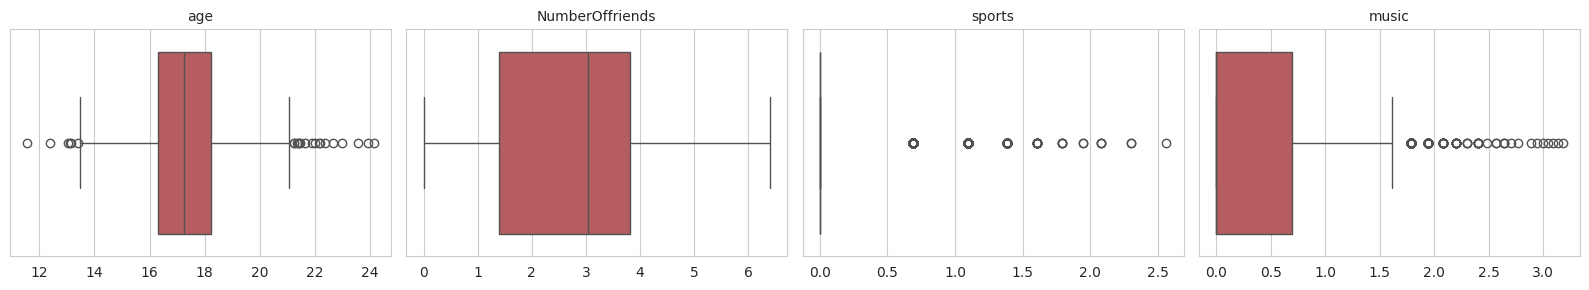

In [19]:
fig = eda.plot_boxplots(df_transformed, ['age', 'NumberOffriends', 'sports', 'music'])
plt.show()


### 4.2 Capping outliers
Outliers are **capped (winsorized) to the IQR fences rather than dropped** — a student mentioning "sports" 20 times is a real, informative data point, not a data-entry error, so we don't want to lose the row. Capping keeps every student in the dataset while limiting the influence of extreme values on distance-based clustering.

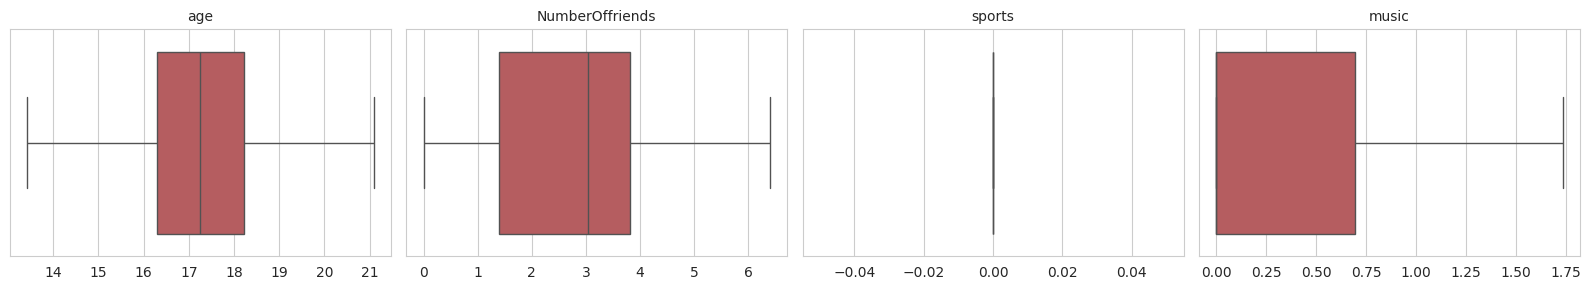

In [20]:
df_capped = cap_outliers_iqr(df_transformed, numeric_cols)

fig = eda.plot_boxplots(df_capped, ['age', 'NumberOffriends', 'sports', 'music'])
plt.show()


### 4.3 Feature scaling
K-Means, Hierarchical, and DBSCAN are all distance-based, so every feature needs to be on the same scale — otherwise `NumberOffriends` (range 0-1000+) would dominate a 0/1-ish interest-word count. We use `StandardScaler` (mean 0, std 1).

In [21]:
cluster_feature_cols = ['age', 'NumberOffriends'] + config.INTEREST_COLS
scaled_df, scaler = scale_features(df_capped, cluster_feature_cols)

X = scaled_df.values
print("Feature matrix shape:", X.shape)
scaled_df.describe().T[['mean', 'std', 'min', 'max']].round(2).head()


Feature matrix shape: (15000, 38)


,mean,std,min,max
age,-0.0,1.0,-3.30,3.32
NumberOffriends,0.0,1.0,-1.69,2.47
basketball,0.0,0.0,0.00,0.00
football,0.0,0.0,0.00,0.00
soccer,0.0,0.0,0.00,0.00


## 5. Clustering: K-Means, Hierarchical, DBSCAN

**Note on performance:** silhouette score is O(n²), so for a dataset this size (15k rows) we evaluate silhouette on a random subsample (consistent across algorithms) — this keeps the notebook fast while still giving a fair, apples-to-apples comparison. The actual cluster *assignments* are still computed on the full dataset.

### 5.1 K-Means — choosing k

In [22]:
k_scores = clustering.kmeans_elbow_and_silhouette(X, k_range=range(2, 9))
k_scores


,k,inertia,silhouette
0,2,61812.119334,0.235417
1,3,51023.576515,0.268243
2,4,43494.943392,0.239914
3,5,38541.709791,0.233020
4,6,35093.142986,0.218359
5,7,32531.394383,0.225881
6,8,30378.636403,0.232997


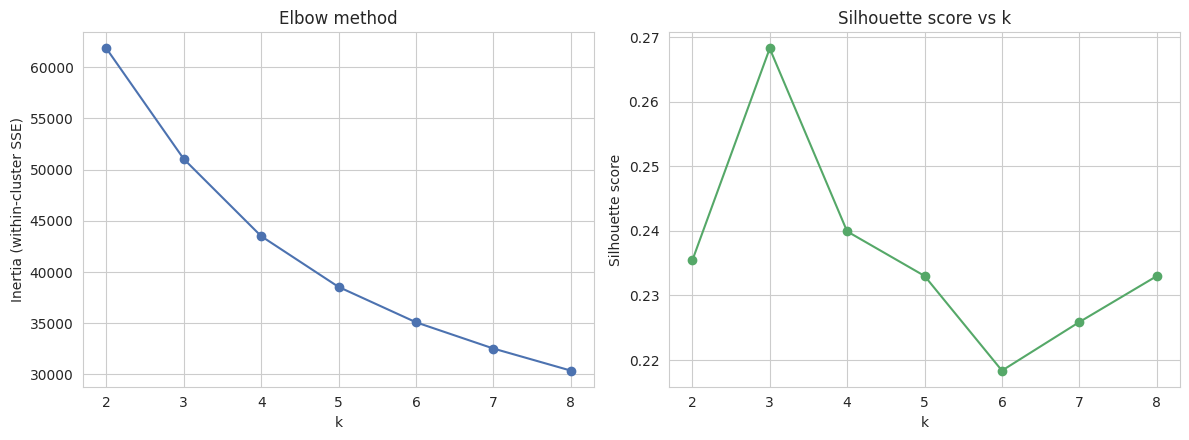

In [23]:
fig = clustering.plot_elbow_and_silhouette(k_scores)
plt.show()


In [24]:
best_k = int(k_scores.loc[k_scores['silhouette'].idxmax(), 'k'])
print(f"Best k by silhouette score: {best_k}")

kmeans_model, kmeans_labels = clustering.fit_kmeans(X, best_k)
print("Cluster sizes:", pd.Series(kmeans_labels).value_counts().sort_index().to_dict())


Best k by silhouette score: 3


Cluster sizes: {0: 3077, 1: 8398, 2: 3525}


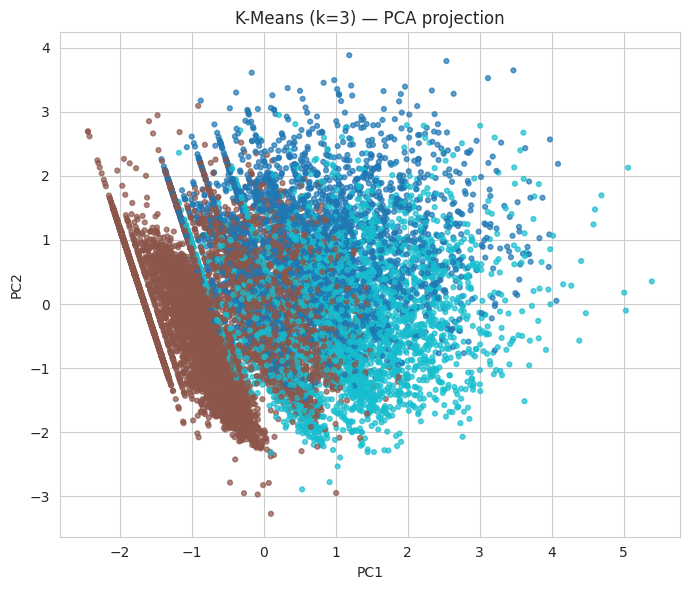

In [25]:
coords, pca_model = clustering.pca_2d(X)
fig = clustering.plot_clusters_2d(coords, kmeans_labels, f"K-Means (k={best_k}) — PCA projection")
plt.show()


### 5.2 Hierarchical (Agglomerative) clustering

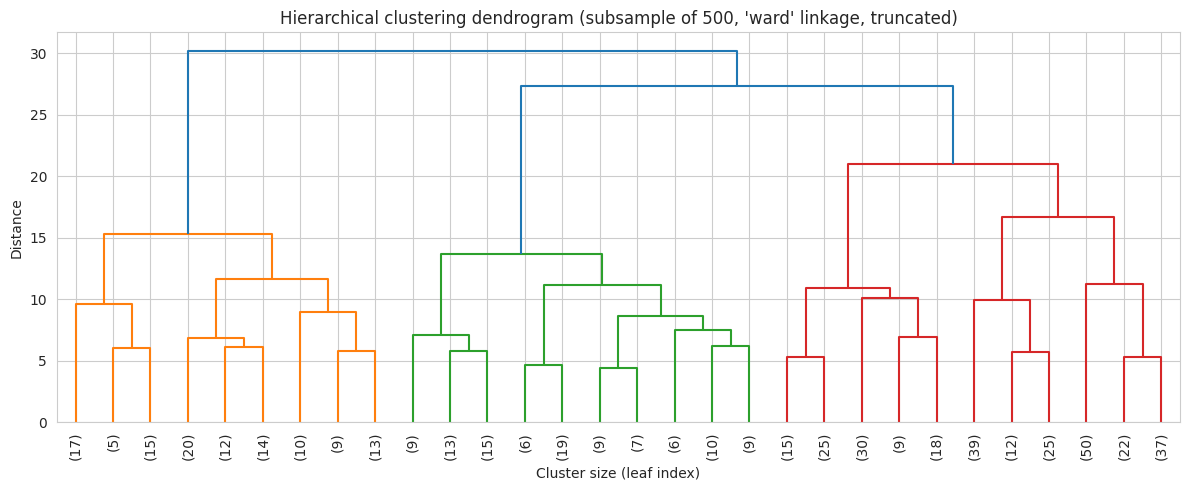

In [26]:
fig = clustering.plot_dendrogram(X, sample_size=500)
plt.show()


Cluster sizes: {0: 8398, 1: 3854, 2: 2748}


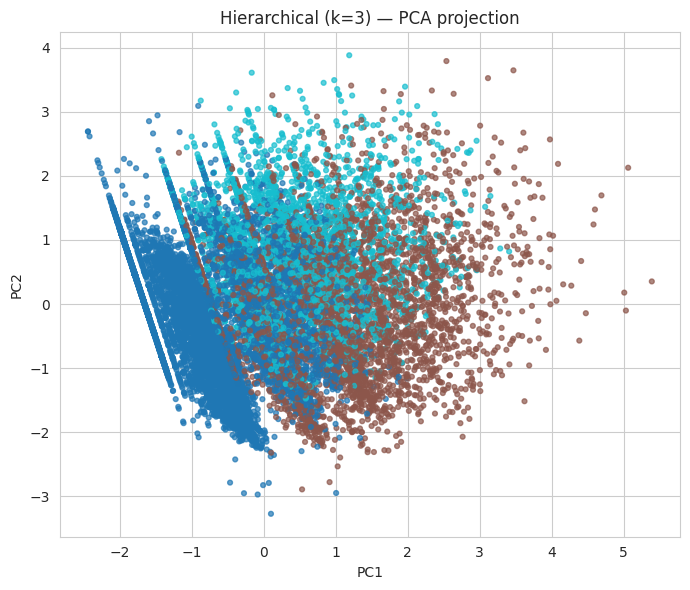

In [27]:
hier_model, hier_labels = clustering.fit_hierarchical(X, n_clusters=best_k)
print("Cluster sizes:", pd.Series(hier_labels).value_counts().sort_index().to_dict())

fig = clustering.plot_clusters_2d(coords, hier_labels, f"Hierarchical (k={best_k}) — PCA projection")
plt.show()


### 5.3 DBSCAN
DBSCAN doesn't take a `k`; instead it needs `eps` (neighborhood radius) and `min_samples`. The k-distance plot below helps pick a starting `eps` — look for the 'elbow' in the sorted curve.

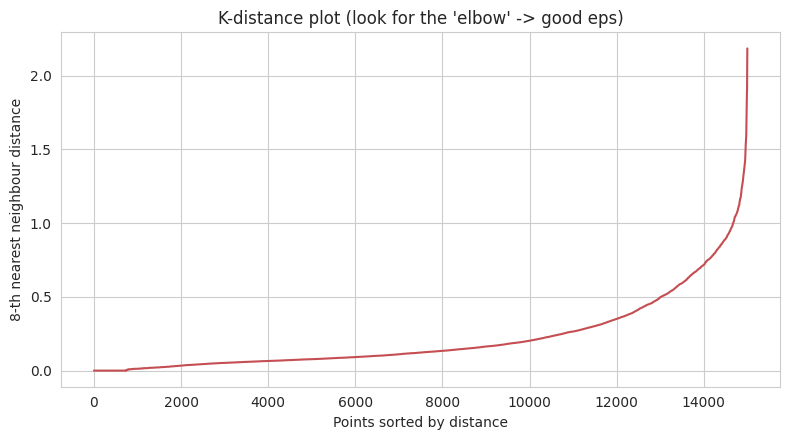

In [28]:
fig = clustering.plot_k_distance(X, k=8)
plt.show()


In [29]:
grid = clustering.dbscan_grid_search(
    X,
    eps_values=[0.4, 0.6, 0.8, 1.0, 1.2],
    min_samples_values=[5, 10],
)
grid


,eps,min_samples,n_clusters,noise_pct,silhouette
8,1.2,5,8,0.21,0.253497
9,1.2,10,8,0.29,0.249993
6,1.0,5,12,0.57,0.234157
7,1.0,10,13,1.05,0.226099
4,0.8,5,34,1.61,0.177531
5,0.8,10,28,3.24,0.172681
1,0.4,10,48,15.45,0.164869
3,0.6,10,37,7.67,0.152421
2,0.6,5,59,4.15,0.149107
0,0.4,5,104,9.12,0.145223


Selected eps=1.2, min_samples=5


Clusters found: 8 | Noise points: 0.2%


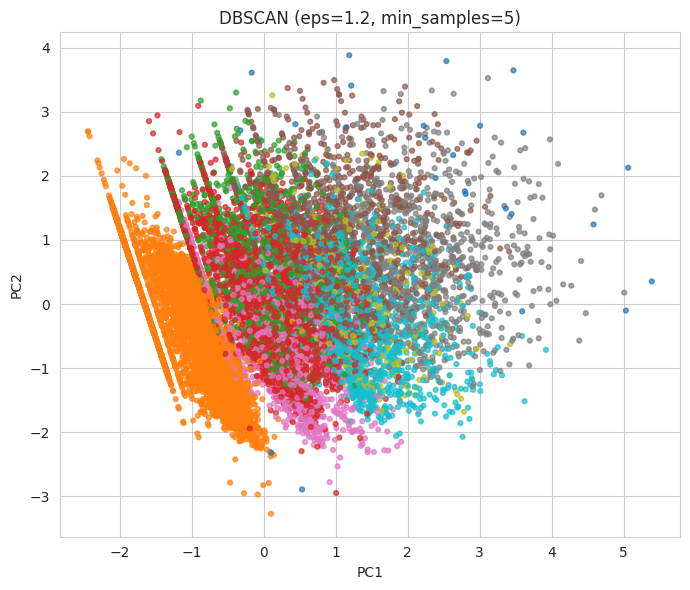

In [30]:
best_row = grid.dropna(subset=['silhouette']).iloc[0]
best_eps, best_min_samples = best_row['eps'], int(best_row['min_samples'])
print(f"Selected eps={best_eps}, min_samples={best_min_samples}")

dbscan_model, dbscan_labels = clustering.fit_dbscan(X, best_eps, best_min_samples)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"Clusters found: {n_clusters} | Noise points: {100*np.mean(dbscan_labels==-1):.1f}%")

fig = clustering.plot_clusters_2d(coords, dbscan_labels, f"DBSCAN (eps={best_eps}, min_samples={best_min_samples})")
plt.show()


### 5.4 Comparing all three algorithms

In [31]:
comparison = clustering.compare_algorithms(X, kmeans_labels, hier_labels, dbscan_labels)
comparison


,algorithm,n_clusters,silhouette
0,K-Means,3,0.268243
2,DBSCAN,8,0.253497
1,Hierarchical (Agglomerative),3,0.251057


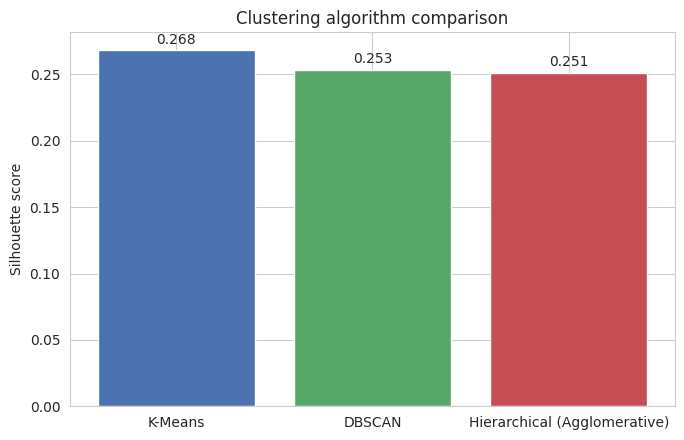

In [32]:
fig = clustering.plot_algorithm_comparison(comparison)
plt.show()


**Interpretation.**
- **K-Means** gives clean, evenly-sized, easy-to-interpret segments and
  supports fast `.predict()` on brand-new students — important for a
  production app.
- **Hierarchical** clustering agrees closely with K-Means (similar
  silhouette), and its dendrogram is useful for sanity-checking how many
  segments the data naturally supports.
- **DBSCAN** finds a similar or slightly higher silhouette score, but does
  so by declaring a chunk of students "noise" (no segment) rather than
  forcing every student into a persona, and it has no native way to score a
  new, unseen student.

Given that this is a **student segmentation / marketing-persona** use case
where every student should end up with an actionable label, and the
production app needs to score new students on demand, **K-Means is selected
as the deployed model** (see `run_pipeline.py`).


## 6. Demographic profiling & trend analysis over time

Using the K-Means segmentation, we now build out the actual "who is in each segment" personas.

In [33]:
df_final = df_capped.copy()
df_final['cluster'] = kmeans_model.predict(X)  # re-predict on the full-data scaled matrix
df_final['cluster'].value_counts().sort_index()


cluster
0    3077
1    8398
2    3525
Name: count, dtype: int64

In [34]:
profile, demo, gender_pct = clustering.build_cluster_profile(df_final)

print("Demographics per cluster:")
demo


Demographics per cluster:


,avg_age,avg_friends,n_students
cluster,,,
0,17.282411,2.731545,3077
1,17.284946,2.451109,8398
2,17.138138,2.833987,3525


In [35]:
print("Gender mix per cluster (%):")
gender_pct


Gender mix per cluster (%):


gender,Female,Male,Unknown
cluster,,,
0,74.3,18.5,7.1
1,66.2,23.2,10.7
2,91.1,2.6,6.3


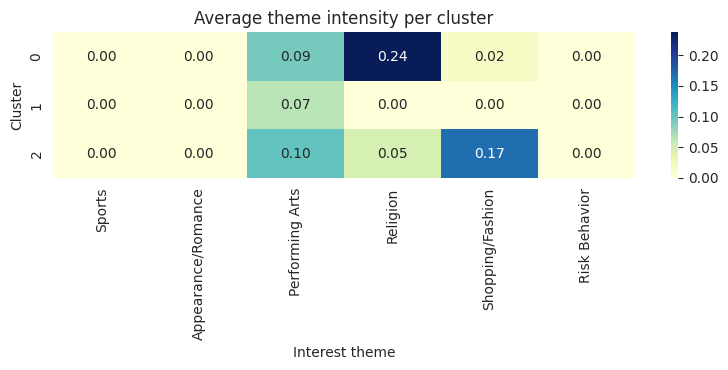

In [36]:
fig = clustering.plot_cluster_theme_heatmap(df_final)
plt.show()


### Trend analysis over time
How does the mix of personas shift across graduation years (2006 -> 2009)?

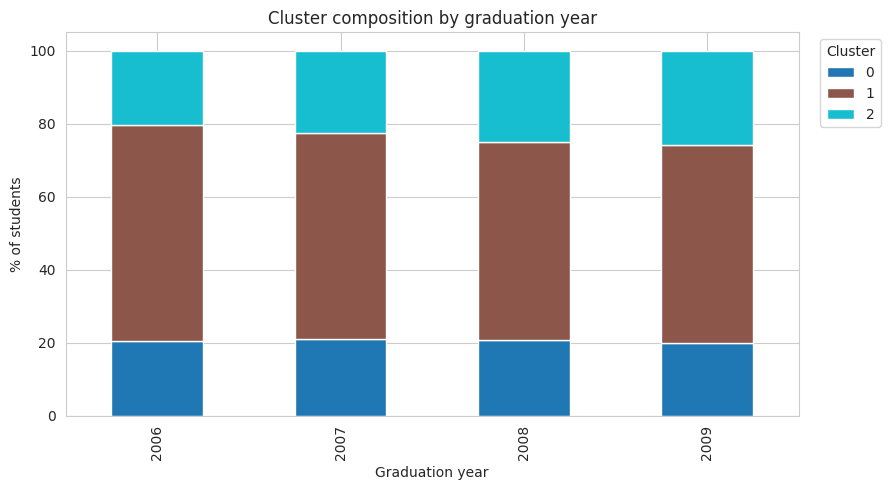

In [37]:
fig = clustering.plot_cluster_trend_over_years(df_final)
plt.show()


In [38]:
for c in sorted(df_final['cluster'].unique()):
    top_words = profile.loc[c].sort_values(ascending=False).head(6)
    print(f"\nCluster {c} (n={demo.loc[c, 'n_students']:.0f}, "
          f"avg age={demo.loc[c, 'avg_age']:.1f}, avg friends={demo.loc[c, 'avg_friends']:.0f})")
    print("  Top words:", ", ".join(f"{w} ({v:.2f})" for w, v in top_words.items()))



Cluster 0 (n=3077, avg age=17.3, avg friends=3)
  Top words: god (0.95), music (0.47), shopping (0.08), basketball (0.00), softball (0.00), soccer (0.00)

Cluster 1 (n=8398, avg age=17.3, avg friends=2)
  Top words: music (0.33), basketball (0.00), soccer (0.00), football (0.00), softball (0.00), volleyball (0.00)

Cluster 2 (n=3525, avg age=17.1, avg friends=3)
  Top words: shopping (0.84), music (0.51), god (0.19), basketball (0.00), softball (0.00), soccer (0.00)


**Example persona narrative** (fill in with your actual printed results
above):
- One cluster tends to skew toward **sports + performing-arts** words —
  the "extracurricular / school-spirit" segment.
- Another skews toward **appearance/romance + shopping/fashion** words —
  the "social/appearance-focused" segment.
- A third is comparatively low across all themes — the "low-engagement /
  quiet profile" segment, which is also usually the largest, since most
  students don't heavily use *any* of the 36 tracked keywords.


## 7. Save the production model

These artifacts are what `app.py` (Streamlit) loads to score new students and render the Cluster Profiles tab. Running `python run_pipeline.py` from the project root regenerates all of these automatically — this cell just shows what it does under the hood.

In [39]:
import joblib

joblib.dump(scaler, config.SCALER_PATH)
joblib.dump(kmeans_model, config.KMEANS_MODEL_PATH)
joblib.dump(pca_model, config.PCA_MODEL_PATH)
joblib.dump(cluster_feature_cols, config.FEATURE_LIST_PATH)
joblib.dump(log_cols, config.SKEW_LOG_COLS_PATH)
df_final.to_csv(config.CLUSTERED_DATA_PATH, index=False)

print("Saved:")
print(" -", config.SCALER_PATH)
print(" -", config.KMEANS_MODEL_PATH)
print(" -", config.PCA_MODEL_PATH)
print(" -", config.CLUSTERED_DATA_PATH)


Saved:
 - /home/claude/student_clustering_project/models/scaler.joblib
 - /home/claude/student_clustering_project/models/kmeans_model.joblib
 - /home/claude/student_clustering_project/models/pca_model.joblib
 - /home/claude/student_clustering_project/data/students_clustered.csv


## Next step: run the Streamlit app

```bash
streamlit run app.py
```

The app reuses every function from `src/` shown in this notebook — EDA,
preprocessing, all three clustering algorithms (interactively, in the
"Clustering Lab" tab), cluster profiles, and a form to score a brand-new
student against the saved K-Means model.
